In [1]:
import pandas as pd # Leer y procesar el CSV
import numpy as np # Trabajar con arrays
from sklearn.preprocessing import MinMaxScaler # Escalar los datos entre 0 y 1
import torch # Uso de pytorch
import torch.nn as nn # Creacion de la red neuronal
import torch.optim as optim # Optimizadores como Adam 
from torch.utils.data import DataLoader, TensorDataset # Entrenar por batches
import matplotlib.pyplot as plt # Hacer las graficas

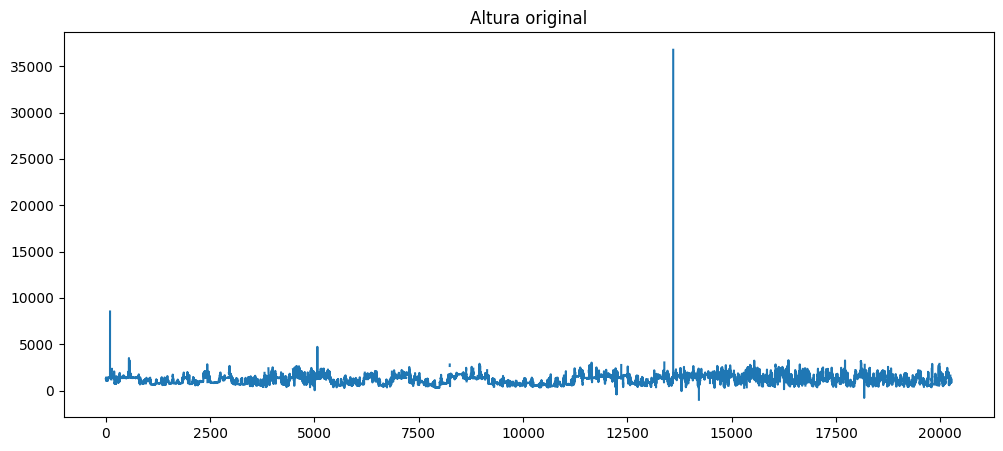

In [2]:
#1. CARGA Y PREPROCESAMIENTO 

BUITRE= "T10"
RUTA_CSV = f"datos_buitre/AviFauna_Muladares/{BUITRE}.csv"

def filtrar_anomalos(df, altura_max=3000, verbose=True):
    df_filtrado = df[df['altura_relativa'] <= altura_max].copy()
    return df_filtrado


#1.CARGA
df = pd.read_csv(RUTA_CSV, low_memory=False)

# Se pone el atributo de dataset timestamp a datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(12,5))
plt.plot(df['height-above-sea'])
plt.title("Altura original")
plt.show()

# Se ordenan cronologicamente porque hay algunos valores que estan desordenados
df = df.sort_values('timestamp')
# Se calcula la altura relativa utilizando las dos variables de altura sobre la altura del mar y sobre el terreno
df['altura_relativa'] = (df['height-above-sea'] - df['height-terrain']).clip(lower=0)
# Se seleccionan las variables importantes
df = df[['timestamp', 'location-lat', 'location-long', 'altura_relativa']]
# Tiempo como indice del dataframe
df = df.set_index('timestamp')
# Se hace un resample cada 10 minutos usando la media interpolando los huecos 
df_resampled = df.resample('10min').mean().interpolate()
# Extrae las tres variables que usará el modelo y las convierte a array NumPy
features = ['location-lat', 'location-long', 'altura_relativa']
data = df_resampled[features].values
# Ajustar el scaler SOLO con los datos de entrenamiento
train_size_raw = int(len(data) * 0.70)

scaler = MinMaxScaler()
scaler.fit(data[:train_size_raw])          # aprende min/max solo del train
data_scaled = scaler.transform(data)       # aplica a todo

In [9]:
# ── 2. VENTANA DESLIZANTE 30 instantes anteriores → predice el instante siguiente

# convierte la serie temporal en ejemplos para la LSTM
# data = lat, long, alt 
def crear_secuencias(data, ventana=50):
    # X= entradas y= salidas (lo que debe predecir)
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i + ventana])
        y.append(data[i + ventana])
    return np.array(X), np.array(y)


ventana = 50
X, y = crear_secuencias(data_scaled, ventana)


In [10]:
# ── 3. DIVISIÓN 70/15/15
# Se crear las divisiones en entrenar, validar y testear
train_size = int(len(X) * 0.70)
val_size   = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val,   y_val   = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test,  y_test  = X[train_size+val_size:], y[train_size+val_size:]

In [11]:
# ── 4. TENSORES Y DATALOADER 
# Funcion para convertir un array de numpy en un tensor de pytorch
def to_tensor(arr): return torch.tensor(arr, dtype=torch.float32)

# Se usa la funcion Dataloader de pytorch, TensorDataset empareja cada entrada con su salida x con y; con esto lo que hacemos es dividir en batches de 64 
train_loader = DataLoader(TensorDataset(to_tensor(X_train), to_tensor(y_train)), batch_size=64, shuffle=False)   # shuffle=False respeta el orden temporal, bactches de 64

# Se convierten en tensores
X_val_t,  y_val_t  = to_tensor(X_val),  to_tensor(y_val)
X_test_t, y_test_t = to_tensor(X_test), to_tensor(y_test)


In [12]:
# ── 5. MODELO LSTM (2 capas, hidden 128, dropout) 
# Se crea una clase LSTM que hereda de todos los modelos de Pytorch, en el constructor ponemos las condiciones que queramos en nuestra LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=2, output_size=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout      # dropout entre capas LSTM para evitar el overlifting
        )
        # Convierte la salida de la LSTM en la prediccion final 128 -> 3
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # último instante temporal

model = LSTMModel()
print(model)

LSTMModel(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [13]:
# 6. ENTRENAMIENTO (100 épocas con early stopping) 
import time
# MSE error cuadratico medio
criterion = nn.MSELoss()
# Algoritmo que actualiza los pesos, lr= velocidad de aprendizaje
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Ajusta automaticamente el learning rate, si no mejora la validacion durante 5 epocas reduce el LR a la mitad
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Maximo numero de iteraciones 
epochs = 100
# Guarda el mejor error de validacion
best_val_loss = float('inf')

patience_counter = 0
PATIENCE = 10   # parar si no mejora en 10 épocas seguidas
start = time.time()
for epoch in range(epochs):
    # — Entrenamiento —
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        # Limpia gradientes anteriores
        optimizer.zero_grad()
        # Calculo del error MSE compara lo predicho con lo real 
        loss = criterion(model(xb), yb)
        # Se propaga el errore hacia atras porque el error esta en la ultima capa
        loss.backward()
        # Actualiza los pesos
        optimizer.step()
        # Suma el error
        train_loss += loss.item()
        # Media del error por batch 
    train_loss /= len(train_loader)

    # — Validación —
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    # — Early stopping —
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Guarda todos los pesos del mejor modelo
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en época {epoch+1}")
            break
end = time.time()
print(f"\nTiempo de entrenamiento: {(end-start)/60:.1f} minutos")

# Cargar el mejor modelo
model.load_state_dict(torch.load("best_model.pt"))

Epoch   1/100 | Train: 0.015815 | Val: 0.005249
Epoch   2/100 | Train: 0.002735 | Val: 0.002258
Epoch   3/100 | Train: 0.002129 | Val: 0.001992
Epoch   4/100 | Train: 0.001895 | Val: 0.002115
Epoch   5/100 | Train: 0.001746 | Val: 0.002021
Epoch   6/100 | Train: 0.001592 | Val: 0.001711
Epoch   7/100 | Train: 0.001581 | Val: 0.002785
Epoch   8/100 | Train: 0.001379 | Val: 0.001763
Epoch   9/100 | Train: 0.000720 | Val: 0.000700
Epoch  10/100 | Train: 0.000452 | Val: 0.000441
Epoch  11/100 | Train: 0.000386 | Val: 0.000423
Epoch  12/100 | Train: 0.000430 | Val: 0.000512
Epoch  13/100 | Train: 0.000467 | Val: 0.000524
Epoch  14/100 | Train: 0.000393 | Val: 0.000773
Epoch  15/100 | Train: 0.000382 | Val: 0.000634
Epoch  16/100 | Train: 0.000341 | Val: 0.000643
Epoch  17/100 | Train: 0.000361 | Val: 0.000700
Epoch  18/100 | Train: 0.000292 | Val: 0.000360
Epoch  19/100 | Train: 0.000194 | Val: 0.000193
Epoch  20/100 | Train: 0.000165 | Val: 0.000172
Epoch  21/100 | Train: 0.000146 | Val: 0

<All keys matched successfully>

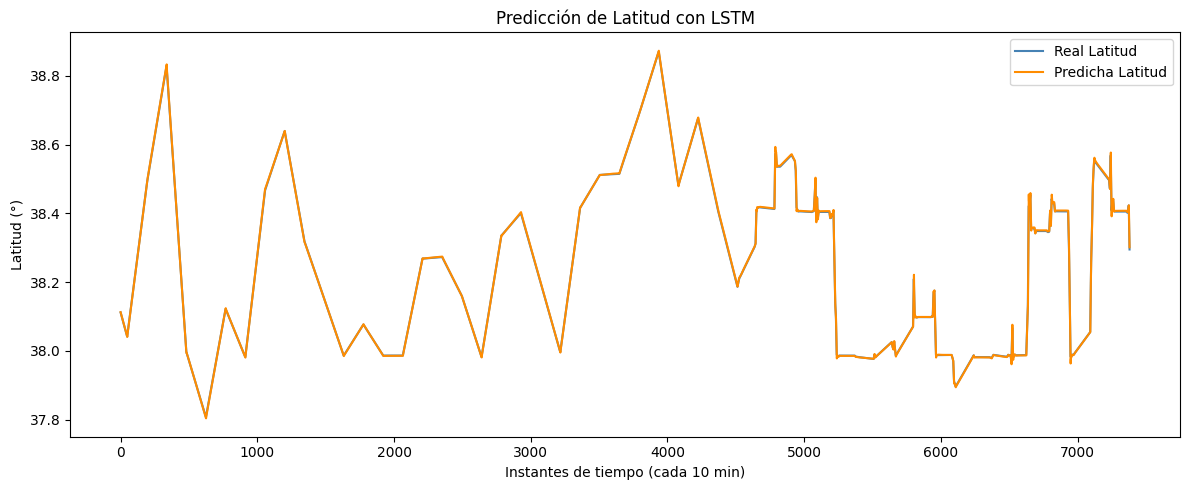

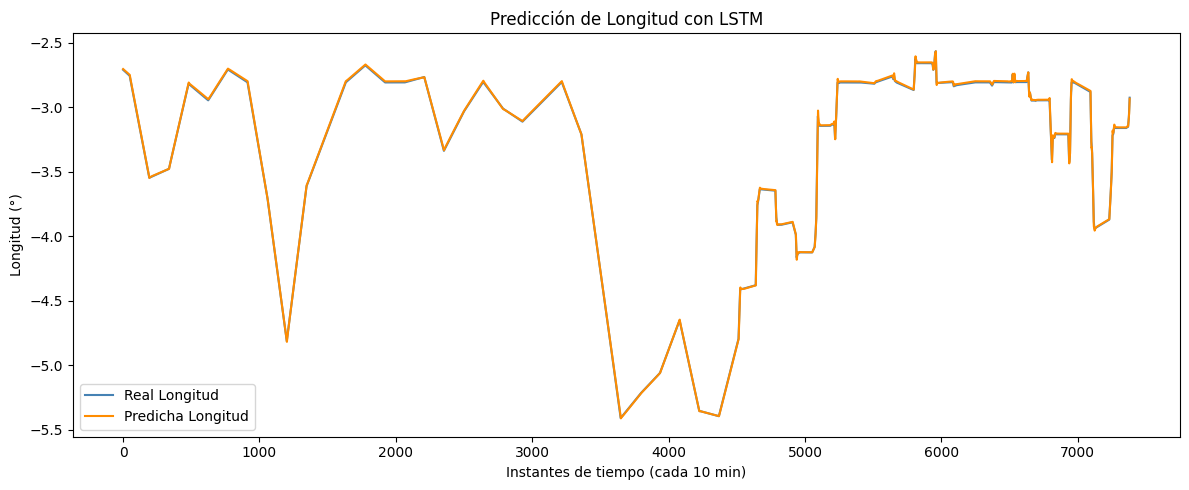

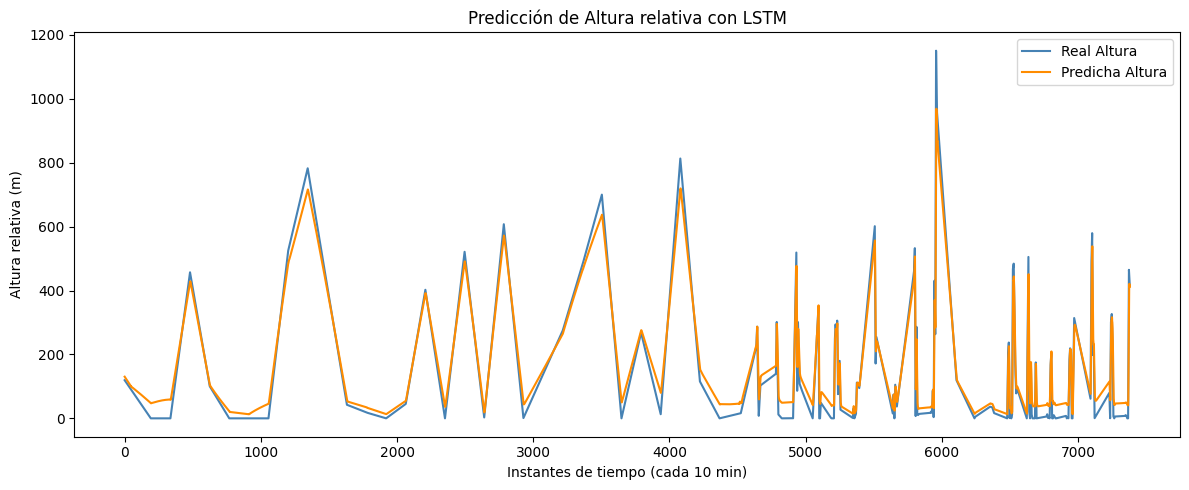

─── Latitud ────────────────────────────
  MAE:  0.0014 grados
  RMSE: 0.0026 grados
─── Longitud ───────────────────────────
  MAE:  0.0055 grados
  RMSE: 0.0069 grados
─── Altura relativa ────────────────────
  MAE:  25.34 metros
  RMSE: 32.52 metros


In [14]:
# 7. PREDICCIÓN Y GRÁFICA 
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
with torch.no_grad():
    predictions = model(X_test_t).numpy()

y_test_np = y_test_t.numpy()

# Desescala para poder trabajar con valores reales
predictions_real = scaler.inverse_transform(predictions)
y_test_real      = scaler.inverse_transform(y_test_np)

# — Gráfica Latitud —
plt.figure(figsize=(12, 5))
plt.plot(y_test_real[:, 0],      label="Real Latitud",    color="steelblue")
plt.plot(predictions_real[:, 0], label="Predicha Latitud", color="darkorange")
plt.legend()
plt.title("Predicción de Latitud con LSTM")
plt.xlabel("Instantes de tiempo (cada 10 min)")
plt.ylabel("Latitud (°)")
plt.tight_layout()
plt.show()

# — Gráfica Longitud —
plt.figure(figsize=(12, 5))
plt.plot(y_test_real[:, 1],      label="Real Longitud",    color="steelblue")
plt.plot(predictions_real[:, 1], label="Predicha Longitud", color="darkorange")
plt.legend()
plt.title("Predicción de Longitud con LSTM")
plt.xlabel("Instantes de tiempo (cada 10 min)")
plt.ylabel("Longitud (°)")
plt.tight_layout()
plt.show()

# — Gráfica Altura relativa —
plt.figure(figsize=(12, 5))
plt.plot(y_test_real[:, 2],      label="Real Altura",    color="steelblue")
plt.plot(predictions_real[:, 2], label="Predicha Altura", color="darkorange")
plt.legend()
plt.title("Predicción de Altura relativa con LSTM")
plt.xlabel("Instantes de tiempo (cada 10 min)")
plt.ylabel("Altura relativa (m)")
plt.tight_layout()
plt.show()

# — Métricas —
mae_lat  = mean_absolute_error(y_test_real[:, 0], predictions_real[:, 0])
rmse_lat = np.sqrt(mean_squared_error(y_test_real[:, 0], predictions_real[:, 0]))

mae_lon  = mean_absolute_error(y_test_real[:, 1], predictions_real[:, 1])
rmse_lon = np.sqrt(mean_squared_error(y_test_real[:, 1], predictions_real[:, 1]))

mae_alt  = mean_absolute_error(y_test_real[:, 2], predictions_real[:, 2])
rmse_alt = np.sqrt(mean_squared_error(y_test_real[:, 2], predictions_real[:, 2]))

print("─── Latitud ────────────────────────────")
print(f"  MAE:  {mae_lat:.4f} grados")
print(f"  RMSE: {rmse_lat:.4f} grados")

print("─── Longitud ───────────────────────────")
print(f"  MAE:  {mae_lon:.4f} grados")
print(f"  RMSE: {rmse_lon:.4f} grados")

print("─── Altura relativa ────────────────────")
print(f"  MAE:  {mae_alt:.2f} metros")
print(f"  RMSE: {rmse_alt:.2f} metros")